# Biblioteca UNDAC — Entrenamiento de modelos de afluencia

Etapa 3 del prototipo. Se comparan Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting mediante una prueba temporal. La selección prioriza F1 macro y el recall del nivel Alto.

> Las métricas corresponden a datos sintéticos y demuestran el funcionamiento técnico, no el rendimiento definitivo con datos institucionales.

## 1. Librerías y carga de datos

In [1]:
from pathlib import Path
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             recall_score, classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEMILLA = 42
print('scikit-learn:', sklearn.__version__)

ruta = Path('ml/data/dataset_afluencia_sintetico.csv')
if not ruta.exists():
    ruta = Path('dataset_afluencia_sintetico.csv')
if not ruta.exists():
    try:
        from google.colab import files
        print('Selecciona dataset_afluencia_sintetico.csv')
        cargados = files.upload()
        ruta = Path(next(n for n in cargados if n.lower().endswith('.csv')))
    except (ImportError, StopIteration):
        raise FileNotFoundError('No se encontró el dataset.')

df = pd.read_csv(ruta, encoding='utf-8-sig')
df['Fecha'] = pd.to_datetime(df['Fecha'])
print(f'Dataset cargado: {len(df):,} filas')

scikit-learn: 1.6.1
Selecciona dataset_afluencia_sintetico.csv


Saving dataset_afluencia_sintetico.csv to dataset_afluencia_sintetico.csv
Dataset cargado: 10,218 filas


## 2. Reconstrucción reproducible de entrenamiento, prueba y niveles

In [2]:
fechas = sorted(df['Fecha'].drop_duplicates())
posicion_corte = max(1, int(len(fechas) * 0.80))
fecha_corte = fechas[posicion_corte - 1]
train = df[df['Fecha'] <= fecha_corte].copy()
test = df[df['Fecha'] > fecha_corte].copy()

base_umbrales = train[train['EsFeriado'] == 0]
umbrales = (base_umbrales.groupby('Sede')['CantidadIngresos']
            .quantile([0.33, 0.67]).unstack()
            .rename(columns={0.33: 'UmbralBajo', 0.67: 'UmbralAlto'}))

def asignar_nivel(fila):
    bajo = umbrales.loc[fila['Sede'], 'UmbralBajo']
    alto = umbrales.loc[fila['Sede'], 'UmbralAlto']
    if fila['CantidadIngresos'] <= bajo:
        return 'Bajo'
    if fila['CantidadIngresos'] <= alto:
        return 'Medio'
    return 'Alto'

train['NivelAfluencia'] = train.apply(asignar_nivel, axis=1)
test['NivelAfluencia'] = test.apply(asignar_nivel, axis=1)
print(f'Corte temporal: {fecha_corte.date()}')
print(f'Entrenamiento: {len(train):,} | Prueba: {len(test):,}')

Corte temporal: 2026-07-23
Entrenamiento: 8,112 | Prueba: 2,106


## 3. Preprocesamiento y modelos

In [3]:
variables = ['Hora', 'Sede', 'NumeroDiaSemana', 'Mes',
             'EsFeriado', 'EsVacaciones', 'PeriodoAcademico']
numericas = ['Hora', 'NumeroDiaSemana', 'Mes', 'EsFeriado', 'EsVacaciones']
categoricas = ['Sede', 'PeriodoAcademico']

X_train = train[variables].copy()
y_train = train['NivelAfluencia'].copy()
X_test = test[variables].copy()
y_test = test['NivelAfluencia'].copy()

preprocesador = ColumnTransformer([
    ('numericas', StandardScaler(), numericas),
    ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas)
])

modelos = {
    'Regresión logística': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=SEMILLA),
    'Árbol de decisión': DecisionTreeClassifier(
        max_depth=9, min_samples_leaf=12, class_weight='balanced', random_state=SEMILLA),
    'Random Forest': RandomForestClassifier(
        n_estimators=250, max_depth=12, min_samples_leaf=5,
        class_weight='balanced_subsample', random_state=SEMILLA, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=180, learning_rate=0.05, max_depth=3, random_state=SEMILLA)
}
print('Modelos preparados:', ', '.join(modelos))

Modelos preparados: Regresión logística, Árbol de decisión, Random Forest, Gradient Boosting


## 4. Entrenamiento y evaluación

Se aplican pesos balanceados para reducir el efecto del predominio de la clase Bajo.

In [4]:
resultados = []
pipelines = {}
predicciones = {}

for nombre, estimador in modelos.items():
    pipeline = Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', estimador)
    ])
    parametros_fit = {}
    if nombre == 'Gradient Boosting':
        parametros_fit['modelo__sample_weight'] = compute_sample_weight('balanced', y_train)
    pipeline.fit(X_train, y_train, **parametros_fit)
    y_pred = pipeline.predict(X_test)

    precision, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0)
    recall_alto = recall_score(
        y_test, y_pred, labels=['Alto'], average=None, zero_division=0)[0]

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_macro': precision,
        'Recall_macro': recall_macro,
        'F1_macro': f1_macro,
        'Recall_Alto': recall_alto
    })
    pipelines[nombre] = pipeline
    predicciones[nombre] = y_pred

resultados_df = pd.DataFrame(resultados)
resultados_df['PuntajeSeleccion'] = (
    0.60 * resultados_df['F1_macro'] + 0.40 * resultados_df['Recall_Alto'])
resultados_df = resultados_df.sort_values(
    ['PuntajeSeleccion', 'F1_macro'], ascending=False).reset_index(drop=True)
display(resultados_df.round(4))

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,Recall_Alto,PuntajeSeleccion
0,Gradient Boosting,0.7298,0.5523,0.6392,0.5580,0.7905,0.6510
1,Árbol de decisión,0.6771,0.5140,0.6139,0.5361,0.7365,0.6162
2,Random Forest,0.7170,0.5231,0.5983,0.5275,0.7095,0.6003
3,Regresión logística,0.6985,0.3949,0.4203,0.4072,0.0000,0.2443


## 5. Comparación con una referencia ingenua

In [5]:
prediccion_base = pd.Series('Bajo', index=y_test.index)
accuracy_base = accuracy_score(y_test, prediccion_base)
recall_alto_base = recall_score(
    y_test, prediccion_base, labels=['Alto'], average=None, zero_division=0)[0]
print(f'Referencia que siempre predice Bajo — Accuracy: {accuracy_base:.4f}')
print(f'Referencia que siempre predice Bajo — Recall Alto: {recall_alto_base:.4f}')
print('Una accuracy alta no basta si el sistema nunca detecta el nivel Alto.')

Referencia que siempre predice Bajo — Accuracy: 0.7118
Referencia que siempre predice Bajo — Recall Alto: 0.0000
Una accuracy alta no basta si el sistema nunca detecta el nivel Alto.


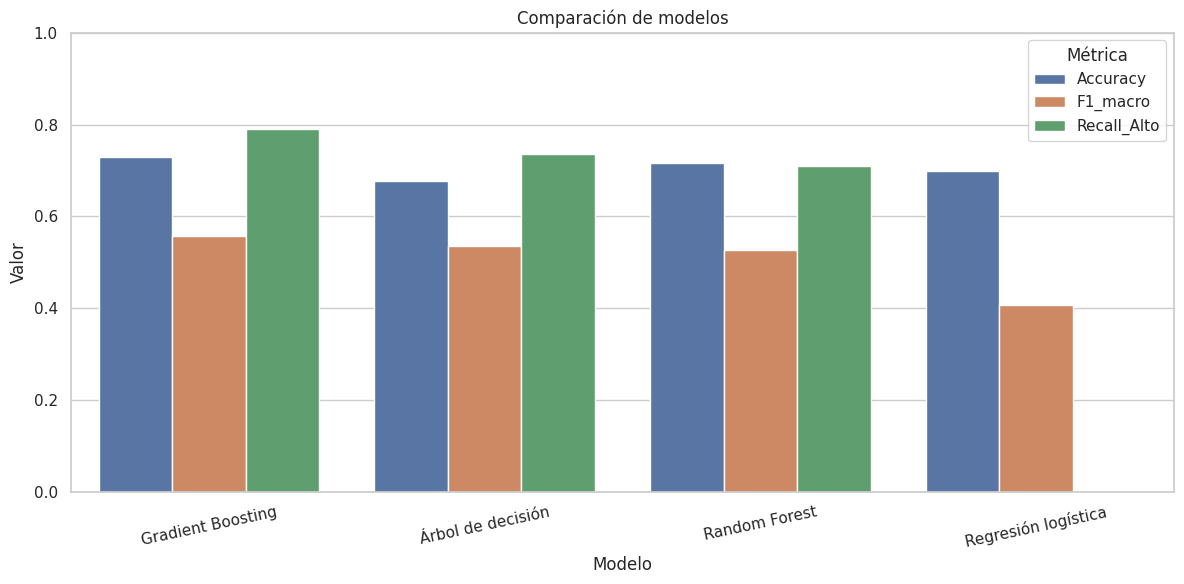

In [6]:
metricas_grafico = resultados_df.melt(
    id_vars='Modelo', value_vars=['Accuracy', 'F1_macro', 'Recall_Alto'],
    var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=metricas_grafico, x='Modelo', y='Valor', hue='Métrica')
plt.ylim(0, 1)
plt.title('Comparación de modelos')
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

## 6. Modelo seleccionado y matriz de confusión

In [7]:
mejor_nombre = resultados_df.iloc[0]['Modelo']
mejor_modelo = pipelines[mejor_nombre]
mejor_prediccion = predicciones[mejor_nombre]
etiquetas = ['Bajo', 'Medio', 'Alto']
print('Modelo seleccionado:', mejor_nombre)
print(classification_report(y_test, mejor_prediccion, labels=etiquetas, zero_division=0))

Modelo seleccionado: Gradient Boosting
              precision    recall  f1-score   support

        Bajo       0.87      0.87      0.87      1499
       Medio       0.45      0.26      0.33       459
        Alto       0.34      0.79      0.48       148

    accuracy                           0.73      2106
   macro avg       0.55      0.64      0.56      2106
weighted avg       0.74      0.73      0.72      2106



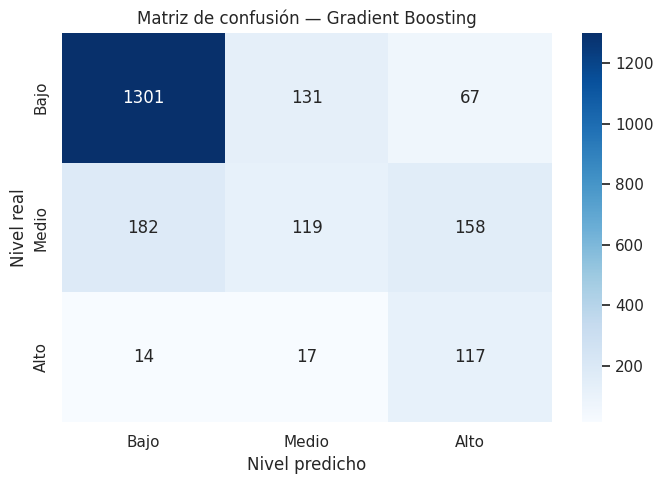

In [8]:
matriz = confusion_matrix(y_test, mejor_prediccion, labels=etiquetas)
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title(f'Matriz de confusión — {mejor_nombre}')
plt.xlabel('Nivel predicho')
plt.ylabel('Nivel real')
plt.tight_layout()
plt.show()

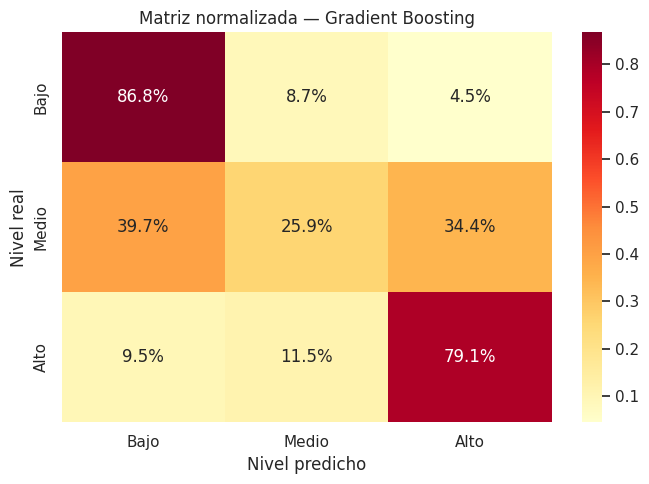

In [9]:
matriz_norm = confusion_matrix(y_test, mejor_prediccion, labels=etiquetas, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_norm, annot=True, fmt='.1%', cmap='YlOrRd',
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title(f'Matriz normalizada — {mejor_nombre}')
plt.xlabel('Nivel predicho')
plt.ylabel('Nivel real')
plt.tight_layout()
plt.show()

## Conclusión de la Etapa 3

El modelo ganador queda almacenado temporalmente en la variable `mejor_modelo`. En la Etapa 4 se entrenará la versión exportable, se guardarán sus metadatos y se realizarán predicciones manuales antes de integrarlo con Flask.